In [37]:
import pandas as pd
import psycopg2

In [38]:
# Database connection parameters
DB_NAME = 'bank_reviews'
DB_USER = 'postgres'
DB_PASSWORD = '1024'
DB_HOST = 'localhost'  
DB_PORT = '5432' 

In [39]:
df = pd.read_csv("bank_reviews_with_sentiment_and_themes.csv")

In [40]:
df[:1]

,review,rating,date,bank,source,sentiment,identified_theme
0,what is this app problem???,1,2025-06-05,CBE,Google Play Store,NEGATIVE,Other


In [41]:
try:
    conn = psycopg2.connect(
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT
    )
    cursor = conn.cursor()
    
    # Insert data into the reviews table
    for index, row in df.iterrows():
        cursor.execute("""
            INSERT INTO reviews (review, rating, date, bank, source, sentiment, identified_theme)
            VALUES (%s, %s, %s, %s, %s, %s, %s)
        """, (row['review'], row['rating'], row['date'], row['bank'], row['source'], row['sentiment'], row['identified_theme']))

    conn.commit()
    print("Data inserted successfully.")

except Exception as e:
    print("Error:", e)


Data inserted successfully.


In [18]:
def insert_banks():
    banks = ['CBE', 'BOA', 'Dashen']
    
    try:
        conn = psycopg2.connect(
            dbname=DB_NAME,
            user=DB_USER,
            password=DB_PASSWORD,
            host=DB_HOST,
            port=DB_PORT
        )
        cursor = conn.cursor()

        for bank in banks:
            cursor.execute("INSERT INTO banks (name) VALUES (%s);", (bank,))
        
        conn.commit()
        print("Banks inserted successfully.")

    except Exception as e:
        print("Error:", e)
        if conn:
            conn.rollback()  # Rollback the transaction on error

    finally:
        if cursor:
            cursor.close()
        if conn:
            conn.close()

if __name__ == "__main__":

    insert_banks()   # Then insert the banks

Banks inserted successfully.


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [44]:
def read_data():
    try:
        conn = psycopg2.connect(
            dbname=DB_NAME,
            user=DB_USER,
            password=DB_PASSWORD,
            host=DB_HOST,
            port=DB_PORT
        )
        query = """
            SELECT r.review, r.rating, r.date, r.bank, r.source, r.sentiment, r.identified_theme, b.id
            FROM reviews r
            JOIN banks b ON r.bank = b.bank;
        """
        df = pd.read_sql(query, conn)
        return df
    except Exception as e:
        print("Error:", e)
    finally:
        if conn:
            conn.close()

# Load the data
data = read_data()

/tmp/ipykernel_25487/2194743599.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [45]:
data

,review,rating,date,bank,source,sentiment,identified_theme,id
0,what is this app problem???,1,2025-06-05,CBE,Google Play Store,NEGATIVE,Other,1
1,the app is proactive and a good connections.,5,2025-06-05,CBE,Google Play Store,POSITIVE,Other,1
2,I cannot send to cbebirr app. through this app.,3,2025-06-05,CBE,Google Play Store,NEGATIVE,Other,1
3,good,4,2025-06-05,CBE,Google Play Store,POSITIVE,Other,1
4,not functional,1,2025-06-05,CBE,Google Play Store,NEGATIVE,Other,1
...,...,...,...,...,...,...,...,...
6664,Faster and userfriendly,5,2025-01-14,Dashen,Google Play Store,POSITIVE,Other,3
6665,"Waw Great and innovated,user friendly, always ...",5,2025-01-13,Dashen,Google Play Store,POSITIVE,Other,3
6666,It's Best waww 🙏,5,2025-01-13,Dashen,Google Play Store,POSITIVE,Other,3
6667,Always one step ahead,5,2025-01-13,Dashen,Google Play Store,POSITIVE,Other,3


In [52]:
# Insights: Identify drivers and pain points
def derive_insights(df):
    # Identify drivers and pain points
    drivers = ['fast navigation', 'user-friendly interface', 'reliable performance']
    pain_points = ['crashes', 'slow loading times', 'difficult navigation']
    sentiment_summary = df.groupby(['bank', 'sentiment']).size().unstack(fill_value=0)
    print("Sentiment Summary:\n", sentiment_summary)

    rating_summary = df.groupby('bank')['rating'].describe()
    print("Rating Summary:\n", rating_summary)

    return drivers, pain_points

drivers, pain_points = derive_insights(data)

Sentiment Summary:
 sentiment  NEGATIVE  POSITIVE
bank                         
BOA             556       231
CBE            2447      3073
Dashen           95       267
Rating Summary:
          count      mean       std  min  25%  50%  75%  max
bank                                                       
BOA      787.0  2.620076  1.812244  1.0  1.0  1.0  5.0  5.0
CBE     5520.0  3.843478  1.588072  1.0  3.0  5.0  5.0  5.0
Dashen   362.0  4.400552  1.272901  1.0  5.0  5.0  5.0  5.0


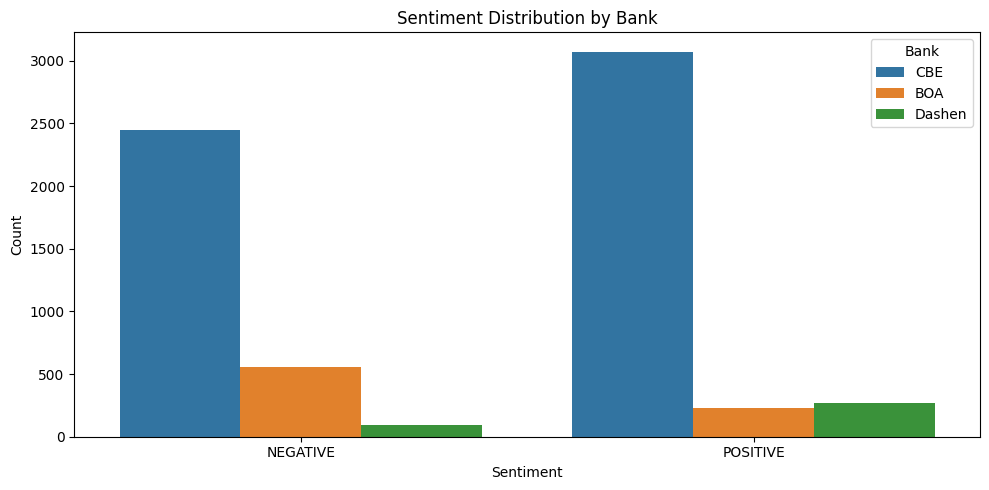

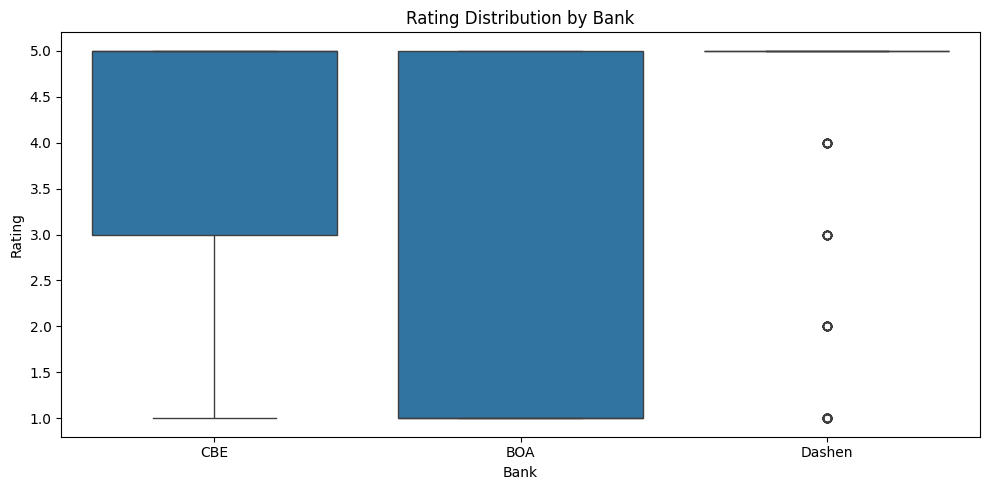

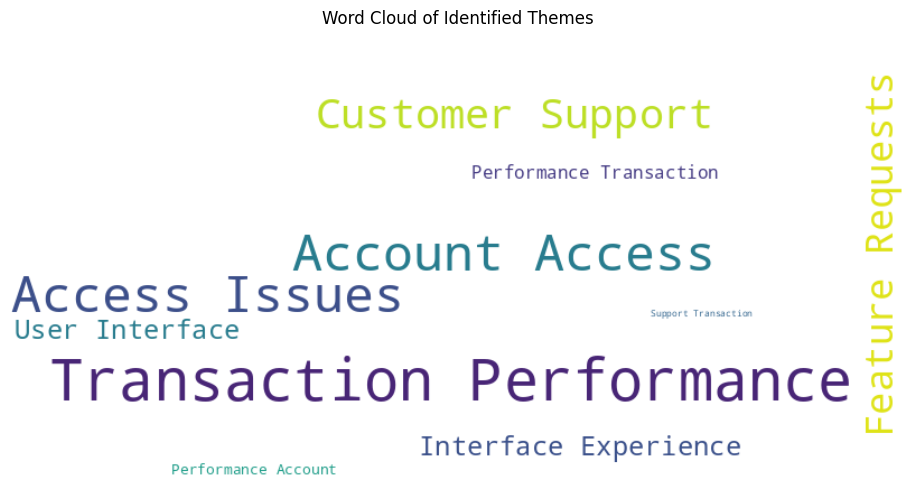

In [51]:
# Visualization: Sentiment Trends
def visualize_sentiment(df):
    # Sentiment Bar Plot
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='sentiment', hue='bank')
    plt.title('Sentiment Distribution by Bank')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.legend(title='Bank')
    plt.tight_layout()
    plt.savefig('sentiment_distribution.png')
    plt.show()

# Visualization: Rating Distribution
def visualize_ratings(df):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='bank', y='rating')
    plt.title('Rating Distribution by Bank')
    plt.xlabel('Bank')
    plt.ylabel('Rating')
    plt.tight_layout()
    plt.savefig('rating_distribution.png')
    plt.show()

# Visualization: Word Cloud for Themes
def visualize_wordcloud(df):
    text = ' '.join(df['identified_theme'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Identified Themes')
    plt.tight_layout()
    plt.savefig('wordcloud_themes.png')
    plt.show()

# Call visualization functions
visualize_sentiment(data)
visualize_ratings(data)
visualize_wordcloud(data)

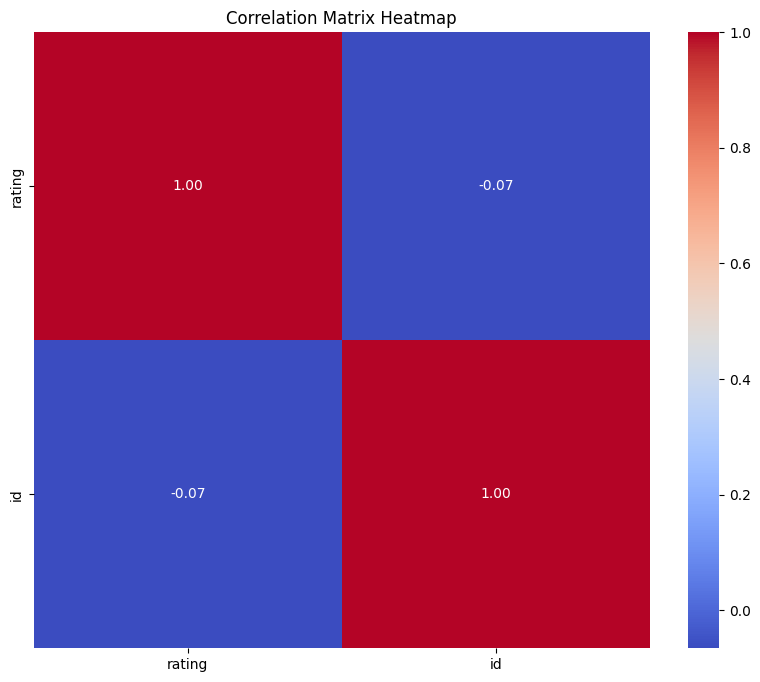

In [54]:
numeric_df = data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()


     bank  review_count  average_rating
0     BOA           787        2.620076
1     CBE          5520        3.843478
2  Dashen           362        4.400552


/tmp/ipykernel_25487/3700999733.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='bank', y='review_count', palette='viridis')
/tmp/ipykernel_25487/3700999733.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='bank', y='average_rating', palette='coolwarm')


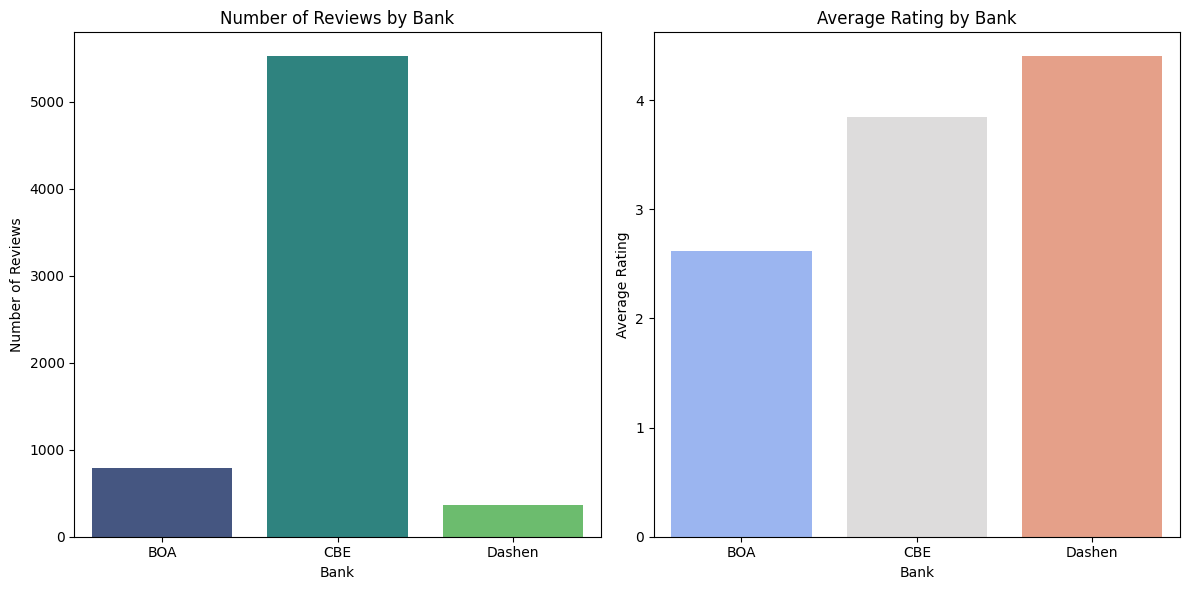

In [55]:

# Count the number of reviews and calculate average ratings
review_counts = data.groupby('bank')['review'].count().reset_index(name='review_count')
average_ratings = data.groupby('bank')['rating'].mean().reset_index(name='average_rating')

# Merge the two DataFrames
summary_df = pd.merge(review_counts, average_ratings, on='bank')

# Display the summary DataFrame
print(summary_df)

# Optional: Visualize the counts and average ratings
plt.figure(figsize=(12, 6))

# Bar plot for review counts
plt.subplot(1, 2, 1)
sns.barplot(data=summary_df, x='bank', y='review_count', palette='viridis')
plt.title('Number of Reviews by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')

# Bar plot for average ratings
plt.subplot(1, 2, 2)
sns.barplot(data=summary_df, x='bank', y='average_rating', palette='coolwarm')
plt.title('Average Rating by Bank')
plt.xlabel('Bank')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()